# BÔNUS MACHINE LEARNING - SEGMENTAÇÃO DE USUÁRIOS VIA K-MEANS

Com o objetivo de complementar a análise exploratória, aplicou-se o algoritmo de agrupamento K-Means para mapear os padrões ocultos na base de dados, respondendo a quatro perguntas de negócio essenciais:

- `Existem perfis naturais de usuários dentro da plataforma?`

- `Quais tipos e perfis de jogadores existem?`

- `Quem são as pessoas que jogam o quiz?`

- `Qual o comportamento detalhado de cada grupo?`

**Abordagem Metodológica**

O K-Means foi escolhido por ser um modelo de aprendizado não supervisionado ideal para descobrir grupos com características semelhantes de forma automatizada.

Para construir os perfis, a modelagem isolou as variáveis comportamentais operacionais do produto, que incluem: o desempenho do jogador "attempts e result", o tempo de tela "time_to_complete_sec", o hábito de acesso "streak_day" e "played_next_day", o canal de entrada "newsletter_open_before_game", a janela de horário "session_hour" e a tecnologia utilizada "device".

In [15]:
# Bibliotecas utilizadas
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Carregar os dados do arquivo CSV para um DataFrame do pandas
df = pd.read_csv('base_dados_tratados/base_palavritas_unificada.csv', sep=',')

# Configuração para exibir todas as variáveis do DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Exibir DataFrame
df.head()

,session_id,user_id,word,word_date,attempts,result,time_to_complete_sec,device,session_hour,streak_day,played_next_day,newsletter_open_before_game,active_d30,word_day_num,attempt_number,guess,correct_letters,correct_positions,age_range,state,salary_range,job_role,sector,company_size,orders_food_delivery,food_delivery_freq_week,food_delivery_platform,primary_device,plays_other_word_games,typical_play_time,newsletter_subscriber
0,ab38635a07ede4246661,697e9e150e91bb76,TEMPO,2026-02-08,1,Win,449,Android,20,2,False,False,False,8,1,TEMPO,0,5,35-44,BA,acima de R$10k,Analista,Finanças,Média,True,2,Nenhum,Android,False,Night,True
1,67d40a22cba1a16fd2c5,d7f63dda905adaec,FALHA,2026-05-08,6,Lose,232,iOS,19,1,True,False,False,8,1,NOVAS,1,0,35-44,PE,R$4k-R$6k,Analista,Tech,Grande,True,7,Rappi,iOS,True,Night,True
2,67d40a22cba1a16fd2c5,d7f63dda905adaec,FALHA,2026-05-08,6,Lose,232,iOS,19,1,True,False,False,8,2,OUVIR,0,0,35-44,PE,R$4k-R$6k,Analista,Tech,Grande,True,7,Rappi,iOS,True,Night,True
3,67d40a22cba1a16fd2c5,d7f63dda905adaec,FALHA,2026-05-08,6,Lose,232,iOS,19,1,True,False,False,8,3,NOVAS,1,0,35-44,PE,R$4k-R$6k,Analista,Tech,Grande,True,7,Rappi,iOS,True,Night,True
4,67d40a22cba1a16fd2c5,d7f63dda905adaec,FALHA,2026-05-08,6,Lose,232,iOS,19,1,True,False,False,8,4,VAPOR,0,1,35-44,PE,R$4k-R$6k,Analista,Tech,Grande,True,7,Rappi,iOS,True,Night,True


In [12]:
# Separação das variáveis comportamentais que serão utilizadas
v_comp = df[[
    'attempts',
    'time_to_complete_sec',
    'streak_day',
    'played_next_day',
    'newsletter_open_before_game',
    'session_hour',
    'device',
    'result'
]].copy()

# Transformação das variáveis categóricas
v_comp = pd.get_dummies(
    v_comp,
    columns=['device', 'result'],
    drop_first=True
)

v_comp.head()

,attempts,time_to_complete_sec,streak_day,played_next_day,newsletter_open_before_game,session_hour,device_iOS,result_Win
0,1,449,2,False,False,20,False,True
1,6,232,1,True,False,19,True,False
2,6,232,1,True,False,19,True,False
3,6,232,1,True,False,19,True,False
4,6,232,1,True,False,19,True,False


In [13]:
# Padronização das variáveis para a mesma escala
scaler = StandardScaler()

v_comp_scaled = scaler.fit_transform(v_comp)

**Análise:** \
Como existem variáveis em escalas muito diferentes, por exemplo:

- attempts → 0 a 8 \
- time_to_complete_sec → 60 a 480 \
- session_hour → 0 a 23

é necessário padronizá-las, antes de rodar o modelo, para que o modelo K-Means calcule a semelhança entre os usuários utilizando a Distância Euclidiana. Se os dados não forem ajustados, o tempo em segundos dominaria completamente o cálculo devido aos seus valores maiores, fazendo com que o algoritmo ignorasse a importância das tentativas ou dos horários. A padronização coloca todas as variáveis na mesma ordem de grandeza, garantindo um agrupamento justo e equilibrado.

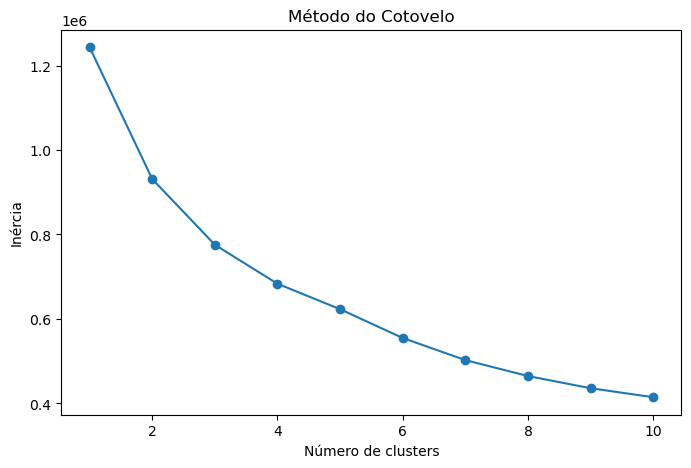

In [ ]:
# Encontrar o número ideal de clusters (agrupamentos)
inercia = []

for k in range(1,11):
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(v_comp_scaled)

    inercia.append(modelo.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inercia, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")
plt.show()

**Análise:** \
Para determinar a quantidade ideal de agrupamentos no K-Means, utiliza-se a análise visual do Método do Cotovelo (Elbow Method). O objetivo desse gráfico é identificar o ponto de inflexão onde a queda da inércia (soma dos quadrados intra-cluster) começa a desacelerar e se estabilizar.

A curva apresenta um declínio acentuado até o cluster 3, consolidando a sua quebra definitiva no cluster 4. A partir do número 4, a linha assume um comportamento suave e quase linear, demonstrando que a adição de novos grupos oferece um ganho marginal irrelevante de ganho estatístico. Portanto, definiu-se a escolha de 4 clusters como a configuração ideal para o projeto, garantindo um modelo simplificado, interpretável e com alta distinção de perfis de jogadores.

In [17]:
# Treinamento do modelo
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(v_comp_scaled)

df['cluster'] = clusters

In [ ]:
# Entendendo os clusters
qnt_clusters = df['cluster'].value_counts()
media_clusters = (df['cluster'].value_counts(normalize=True) * 100).round(2)

print(f'Quantidade geral de clusters:\n{qnt_clusters}\n')
print(f'Média geral de clusters:\n{media_clusters}')

Quantidade geral de clusters:
cluster
1    70806
3    39385
2    24471
0    20754
Name: count, dtype: int64

Média geral de clusters:
cluster
1    45.56
3    25.34
2    15.75
0    13.35
Name: proportion, dtype: float64%


**Análise:** \
Após a execução do algoritmo K-Means configurado para 4 agrupamentos, obteve-se uma distribuição consistente e bem distribuída das 155.416 sessões de jogo da base. A volumetria e o percentual de relevância de cada perfil foram mapeados da seguinte forma:

- **Cluster 1 (Grupo Majoritário):** Possui 70.806 registros, representando 45,56% do total de jogadas da plataforma. É, de forma disparada, o perfil base que dita as principais métricas do produto.
- **Cluster 3 (Grupo Secundário):** Conta com 39.385 registros, equivalendo a 25,34% da base de dados.
- **Cluster 2 (Grupo Intermediário):** Engloba 24.471 registros, o que corresponde a 15,75% das sessões de jogo.
- **Cluster 0 (Grupo de Nicho):** Apresenta 20.754 registros, consolidando-se como o menor grupo, com 13,35% de representatividade.

Essa divisão comprova a eficácia da clusterização: o modelo não concentrou toda a base em um único bloco gigante e nem pulverizou os dados em grupos irrelevantes. Há uma separação nítida de tamanhos que podera ajudar a traçar estratégias de produto segmentadas para cada tipo de jogador.

In [19]:
# Perfil médio
df.groupby('cluster')[[
    'attempts',
    'time_to_complete_sec',
    'streak_day',
    'played_next_day',
    'active_d30'
]].mean().round(2)

,attempts,time_to_complete_sec,streak_day,played_next_day,active_d30
cluster,,,,,
0,6.00,273.00,1.32,1.00,0.59
1,6.00,268.02,1.28,0.00,0.21
2,4.08,273.00,1.29,0.22,0.37
3,2.32,269.32,1.29,0.22,0.31


**Análise e insights**:

A interpretação dos centroides dos clusters revela quatro perfis comportamentais nítidos de jogadores, fornecendo insights profundos de produto:

- **Cluster 3 - O Eficiente (25,3%):** Usuários de alta performance que resolvem o quiz com apenas 2,32 tentativas em média e sustentam uma retenção saudável de 31%.
- **Cluster 2 - O Persistente (15,7%):** Jogadores de nível intermediário (Média: 4,08 tentativas) que se mostram altamente engajados a longo prazo, com 37% de retenção em 30 dias.
- **Cluster 0 - O Fiel Detentor do Hábito (13,3%):** Embora usem o limite máximo de 6 tentativas, possuem 100% de taxa de retorno no dia seguinte e uma retenção crítica espetacular de 59%.
- **Cluster 1 - O Casual Frustrado (45,5%):** O grupo majoritário da plataforma. Esgota as 6 tentativas do jogo, mas registra 0% de retorno imediato no dia seguinte e a pior retenção mensal (21%).

**Conclusão de Negócio:** O jogo tem ótimo engajamento em tempo de tela (~270s), mas o grande desafio é o Cluster 1 (Casual Frustrado), que representa 45,5% da base e não retorna após esgotar as 6 tentativas em rodadas difíceis.

Para resgatar esse público e derrubar o Churn de 69%, propõe-se duas ações focadas:

- **Ajuste de Dificuldade:** Intercalar palavras fáceis e difíceis, evitando o excesso de termos com acentos ou sinais gráficos na mesma semana.
- **Suporte ao Hábito:** Implementar o Modo Treino e o Escudo de Streak para diminuir o peso das derrotas.

Focar essas melhorias no Cluster 1 é a estratégia definitiva para reter o usuário casual e transformá-lo em um jogador fiel.

## Cruzamento com outras variáveis

In [ ]:
# Cruzamento com a variável "device"
pd.crosstab(df['cluster'], df['device'], normalize='index')*100

device,Android,iOS
cluster,,
0,42.584562,57.415438
1,42.869248,57.130752
2,44.403580,55.596420
3,47.525708,52.474292


**Insights:** 

A análise da distribuição de dispositivos por cluster mostra que o uso de Android e iOS é bastante equilibrado entre todos os grupos de usuários. Como a proporção de dispositivos é praticamente a mesma entre jogadores fiéis e frustrados, conclui-se que o tipo de aparelho não influencia a retenção, que está mais relacionada à experiência e à dificuldade do jogo. Assim, novas funcionalidades devem ser implementadas e testadas simultaneamente em ambas as plataformas para alcançar toda a base de usuários.

In [38]:
# Cruzamento com a variável "result"
pd.crosstab(df['cluster'], df['result'], normalize='index')*100

result,Lose,Win
cluster,,
0,100.000000,0.000000
1,100.000000,0.000000
2,47.591026,52.408974
3,0.000000,100.000000


**Insights:**

A análise da variável de resultado (result) por cluster trouxe a validação definitiva para as hipóteses de negócio do projeto, revelando padrões comportamentais extremos:

- **Cluster 0 - O 'Treino Oculto' (13,3%):** Registra 100% de derrotas gastando as 6 tentativas, mas possui 100% de retorno no dia seguinte. Este comportamento valida matematicamente a hipótese de que esses usuários utilizam sessões secundárias ou anônimas para 'esvaziar' o quiz, descobrir a palavra secreta e depois pontuar em suas contas principais.
- **Cluster 1 - A Frustração Real (45,5%):** Também registra 100% de derrotas, mas com 0% de retorno no dia seguinte. É o público casual que perde o jogo de forma legítima, frustra-se com a dificuldade e pune a plataforma abandonando-a no dia seguinte.
- **Cluster 3 - A Alta Performance (25,3%):** Composto por 100% de vitórias rápidas (média de 2,32 tentativas), representando o usuário ideal e altamente habilidoso.
- **Cluster 2 - O Jogador Real Competitivo (15,7%):** Apresenta uma distribuição equilibrada de 52% de vitórias e 48% de derrotas (Média de 4 tentativas). É o perfil mais resiliente e saudável do ecossistema, mantendo a maior retenção de 30 dias (37%)

**Afirmações das recomendações de negocios:** Essa descoberta reforça a necessidade urgente de implementar o Modo Treino oficial na plataforma. Dar ao Cluster 0 uma forma legítima de treinar palavras antigas vai limpar o ruído de 100% de derrotas artificiais na base de dados, enquanto a calibração da dificuldade das palavras salvará o Cluster 1 da evasão em massa.

In [39]:
# Cruzamento com a variável "age_range"
pd.crosstab(df['cluster'], df['age_range'], normalize='index')*100

age_range,18-24,25-34,35-44,45+,Não informado
cluster,,,,,
0,7.458803,23.677363,16.363111,8.962128,43.538595
1,8.101008,24.336921,16.464706,7.702737,43.394628
2,10.003678,25.728413,15.724735,9.447918,39.095256
3,7.317507,23.892345,17.184207,8.333122,43.272820


**Insights:**

A análise por faixa etária reforça que idade não é um fator determinante para retenção ou desempenho, uma vez que a distribuição etária é semelhante entre todos os clusters, com predominância de usuários entre 25 e 34 anos. Além disso, o elevado percentual de perfis "Não informado" no Cluster 0 fortalece a hipótese de que parte dos jogadores realiza partidas anônimas antes de utilizar sua conta principal. Os resultados indicam que o comportamento dos usuários é influenciado principalmente pela experiência de jogo e pelos padrões comportamentais, e não por características demográficas ou técnicas.

In [40]:
# Cruzamento com a variável "salary_range"
pd.crosstab(df['cluster'], df['salary_range'], normalize='index')*100

salary_range,Não informado,R$2k-R$4k,R$4k-R$6k,R$6k-R$10k,acima de R$10k,até R$2k
cluster,,,,,,
0,50.852848,13.067361,12.864990,8.239376,7.950275,7.025152
1,48.428099,12.626049,13.303957,9.304296,8.262012,8.075587
2,48.796535,12.390176,15.565363,9.783008,4.311226,9.153692
3,48.444839,13.098896,13.070966,9.521391,7.584106,8.279802


**Insights:** 

A análise da distribuição de renda mostra que o perfil financeiro dos usuários é bastante homogêneo entre os clusters, com predominância de renda entre R$ 2 mil e R$ 6 mil. A elevada proporção de perfis "Não informado", especialmente no Cluster 0, reforça a hipótese de uso anônimo da plataforma. Os resultados indicam que a renda não é um fator determinante para retenção ou desempenho, sugerindo que as estratégias de melhoria devem priorizar a experiência do usuário e o game design, em vez da segmentação por perfil socioeconômico.

In [41]:
# Cruzamento com a variável "job_role"
pd.crosstab(df['cluster'], df['job_role'], normalize='index')*100

job_role,Analista,Analista Sênior,Analista de Dados,Consultor,Consultor Sênior,Consultor de Dados,Coordenador,Coordenador Sênior,Coordenador de Dados,Desenvolvedor,Desenvolvedor Sênior,Desenvolvedor de Dados,Designer,Designer Sênior,Designer de Dados,Diretor,Diretor Sênior,Diretor de Dados,Engenheiro,Engenheiro Sênior,Engenheiro de Dados,Estudante,Estudante Sênior,Estudante de Dados,Gerente,Gerente Sênior,Gerente de Dados,Não informado,Professor,Professor Sênior,Professor de Dados
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,7.863544,0.346921,0.318011,5.666378,0.809483,0.607112,6.157849,0.173461,0.318011,3.035559,0.231281,0.607112,5.839838,0.202371,0.144550,7.516623,1.011853,0.636022,4.278693,0.520382,0.636022,5.839838,0.462561,0.115640,5.377277,0.636022,0.896213,34.113906,4.914715,0.693842,0.028910
1,6.999407,0.144056,0.338954,5.558851,0.805017,0.550801,5.253792,0.186425,0.457588,4.601305,0.305059,0.644013,5.762224,0.389797,0.161003,7.329887,1.008389,0.525379,4.414880,0.669435,0.635539,6.440132,0.347428,0.194899,6.194390,0.720278,0.576222,33.183629,5.041946,0.525379,0.033895
2,5.165298,0.531241,0.694700,4.319398,0.400474,0.514895,10.064975,1.434351,0.580279,2.803318,0.674268,0.237015,3.559315,0.637489,0.089902,8.822688,0.449512,0.351436,6.587389,0.380042,0.424993,4.008827,0.890850,0.000000,5.953986,0.772343,0.854072,30.329778,6.350374,1.017531,1.099260
3,7.241336,0.162498,0.418941,5.364987,0.695696,0.436714,6.235877,0.373239,0.424019,3.839025,0.297067,0.710931,4.814015,0.632220,0.200584,7.266726,0.886124,0.533198,5.012060,0.484956,0.731243,5.834709,0.401168,0.093944,6.157166,0.743938,0.677923,33.109052,5.629047,0.492573,0.099022


**Insights:**



A análise por cargo indica predominância de profissionais com perfil técnico, analítico e de gestão, como Analistas, Gerentes, Consultores e Engenheiros. O Cluster com maior retenção concentra uma proporção mais elevada de cargos de liderança e menor índice de dados ausentes, sugerindo maior engajamento desses usuários. Os resultados reforçam que o público do Palavritas possui perfil corporativo e analítico, indicando que estratégias voltadas à manutenção do hábito de jogo e melhoria da experiência tendem a ser mais eficazes do que segmentações por perfil profissional.

## Conclusão da segmentação de usuários